# Chapter 11.3: Counterfactual Evaluation

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain why counterfactual evaluation is necessary** for offline evaluation of new recommendation policies
2. **Implement Inverse Propensity Scoring (IPS)** to re-weight logged data for unbiased evaluation
3. **Apply Self-Normalized IPS (SNIPS)** for variance reduction
4. **Build a Doubly Robust (DR) estimator** that combines IPS with a direct method
5. **Understand off-policy evaluation for ranking** in the cascading bandit setting
6. **Estimate propensity scores** from logged data using multiple methods
7. **Compare estimator variance** empirically and understand bias-variance trade-offs

## Prerequisites

- Chapters 11.1 and 11.2
- Basic probability and statistics (conditional probability, expectation)
- Familiarity with importance sampling concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.3_counterfactual.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.3_counterfactual.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Why Counterfactual Evaluation?

In offline evaluation, we have logged data collected under a **logging policy** $\pi_0$. We want to estimate the performance of a **new target policy** $\pi_1$ without deploying it.

The fundamental problem: we only observe outcomes for actions the logging policy took. If $\pi_0$ never recommends item $i$ to user $u$, we have no data on what would have happened.

$$V(\pi_1) = \mathbb{E}_{(x,a) \sim \pi_1}[r(x,a)]$$

But our data comes from $\pi_0$, not $\pi_1$. Naive evaluation is biased.

Reference: Schnabel et al., "Recommendations as Treatments: Debiasing Learning and Evaluation" (ICML 2016).

> **💡 Concept:** Counterfactual evaluation answers: "What *would have* happened if we had used a different recommendation policy?" — without actually running it online.

In [2]:
# --- Simulation Setup ---
# We simulate a simple recommendation scenario:
# - N contexts (users), K actions (items)
# - True reward depends on (context, action)
# - Logging policy selects actions with known propensities
# - Target policy selects different actions

rng = np.random.RandomState(42)
N_CONTEXTS = 5000  # number of logged interactions
K_ACTIONS = 10     # number of items

# Context features (user features)
contexts = rng.randn(N_CONTEXTS, 3)

# True reward function: r(x, a) = sigmoid(x^T w_a + noise)
# Each action has a weight vector
true_weights = rng.randn(K_ACTIONS, 3) * 0.5

def true_reward(context, action):
    """Ground truth expected reward for (context, action) pair."""
    logit = context @ true_weights[action] 
    return expit(logit)

def sample_reward(context, action, rng):
    """Sample a binary reward from the true reward distribution."""
    p = true_reward(context, action)
    return rng.binomial(1, p)

# --- Logging Policy (pi_0): softmax with temperature ---
logging_temp = 1.0
logging_weights = rng.randn(K_ACTIONS, 3) * 0.3  # imperfect model of reward

def logging_policy_probs(context):
    """Probability distribution over actions under logging policy."""
    logits = context @ logging_weights.T / logging_temp
    logits -= logits.max()  # numerical stability
    probs = np.exp(logits)
    return probs / probs.sum()

# --- Target Policy (pi_1): greedy on true rewards (oracle) ---
def target_policy_probs(context):
    """Target policy: picks the best action greedily."""
    rewards = np.array([true_reward(context, a) for a in range(K_ACTIONS)])
    probs = np.zeros(K_ACTIONS)
    probs[np.argmax(rewards)] = 1.0
    return probs

# --- Generate Logged Data ---
logged_data = []
for i in range(N_CONTEXTS):
    x = contexts[i]
    pi0 = logging_policy_probs(x)
    action = rng.choice(K_ACTIONS, p=pi0)
    reward = sample_reward(x, action, rng)
    propensity = pi0[action]
    pi1 = target_policy_probs(x)
    
    logged_data.append({
        'context_idx': i,
        'action': action,
        'reward': reward,
        'propensity': propensity,  # pi_0(a|x)
        'target_prob': pi1[action],  # pi_1(a|x)
    })

log_df = pd.DataFrame(logged_data)

# True value of target policy (computed exactly)
true_value = np.mean([true_reward(contexts[i], np.argmax([true_reward(contexts[i], a) for a in range(K_ACTIONS)]))
                      for i in range(N_CONTEXTS)])

print(f"Logged interactions: {len(log_df)}")
print(f"Average logged reward (pi_0 performance): {log_df['reward'].mean():.4f}")
print(f"True value of target policy (pi_1):       {true_value:.4f}")

Logged interactions: 5000
Average logged reward (pi_0 performance): 0.4982
True value of target policy (pi_1):       0.7220


## 2. Inverse Propensity Scoring (IPS)

IPS re-weights each observation by the importance weight $w = \frac{\pi_1(a|x)}{\pi_0(a|x)}$:

$$\hat{V}_{\text{IPS}}(\pi_1) = \frac{1}{n} \sum_{i=1}^{n} \frac{\pi_1(a_i | x_i)}{\pi_0(a_i | x_i)} \cdot r_i$$

This estimator is **unbiased** when propensities are correct, but can have **high variance** when importance weights are large.

Reference: Horvitz & Thompson (1952); adapted for recommendations by Li et al. (2011).

> **⚠️ Common Pitfall:** If the logging policy assigns very low probability to an action that the target policy prefers, the importance weight explodes, causing extreme variance. Weight clipping helps but introduces bias.

In [3]:
def ips_estimator(rewards, propensities, target_probs, clip=None):
    """Inverse Propensity Scoring estimator.
    
    Args:
        rewards: observed rewards
        propensities: pi_0(a|x) for each observation
        target_probs: pi_1(a|x) for each observation
        clip: optional max importance weight (for clipped IPS)
    """
    weights = target_probs / propensities
    if clip is not None:
        weights = np.clip(weights, 0, clip)
    return np.mean(weights * rewards)

# Compute IPS estimate
ips_estimate = ips_estimator(
    log_df['reward'].values,
    log_df['propensity'].values,
    log_df['target_prob'].values
)

# Clipped IPS
clipped_ips = ips_estimator(
    log_df['reward'].values,
    log_df['propensity'].values,
    log_df['target_prob'].values,
    clip=10.0
)

print(f"True V(pi_1):     {true_value:.4f}")
print(f"IPS estimate:     {ips_estimate:.4f}  (error: {abs(ips_estimate - true_value):.4f})")
print(f"Clipped IPS (10): {clipped_ips:.4f}  (error: {abs(clipped_ips - true_value):.4f})")

# Show importance weight statistics
weights = log_df['target_prob'].values / log_df['propensity'].values
print(f"\nImportance weight stats:")
print(f"  Mean: {weights.mean():.2f}, Std: {weights.std():.2f}, Max: {weights.max():.2f}")

True V(pi_1):     0.7220
IPS estimate:     0.7399  (error: 0.0179)
Clipped IPS (10): 0.5417  (error: 0.1803)

Importance weight stats:
  Mean: 1.03, Std: 3.80, Max: 49.21


## 3. Self-Normalized IPS (SNIPS)

SNIPS normalises the importance weights to sum to 1, reducing variance at the cost of a small bias:

$$\hat{V}_{\text{SNIPS}}(\pi_1) = \frac{\sum_{i=1}^{n} w_i \cdot r_i}{\sum_{i=1}^{n} w_i}, \quad w_i = \frac{\pi_1(a_i|x_i)}{\pi_0(a_i|x_i)}$$

Reference: Swaminathan & Joachims, "The Self-Normalized Estimator for Counterfactual Learning" (NeurIPS 2015).

In [4]:
def snips_estimator(rewards, propensities, target_probs):
    """Self-Normalized Inverse Propensity Scoring estimator."""
    weights = target_probs / propensities
    return np.sum(weights * rewards) / np.sum(weights)

snips_estimate = snips_estimator(
    log_df['reward'].values,
    log_df['propensity'].values,
    log_df['target_prob'].values
)

print(f"True V(pi_1):   {true_value:.4f}")
print(f"IPS estimate:   {ips_estimate:.4f}")
print(f"SNIPS estimate: {snips_estimate:.4f}  (error: {abs(snips_estimate - true_value):.4f})")

True V(pi_1):   0.7220
IPS estimate:   0.7399
SNIPS estimate: 0.7218  (error: 0.0001)


## 4. Doubly Robust (DR) Estimator

The DR estimator combines a direct method (reward model) with IPS correction. It is unbiased if **either** the propensity model **or** the reward model is correct:

$$\hat{V}_{\text{DR}}(\pi_1) = \frac{1}{n} \sum_{i=1}^{n} \left[ \hat{r}(x_i, \pi_1) + \frac{\pi_1(a_i|x_i)}{\pi_0(a_i|x_i)} \left(r_i - \hat{r}(x_i, a_i)\right) \right]$$

where $\hat{r}(x, a)$ is an estimated reward model, and $\hat{r}(x, \pi_1) = \sum_a \pi_1(a|x) \hat{r}(x, a)$.

Reference: Dudik et al., "Doubly Robust Policy Evaluation and Optimization" (2014).

> **🔑 Pro Tip:** DR is the gold standard for off-policy evaluation. Even with an imperfect reward model, the IPS correction compensates. And even with noisy propensities, the reward model baseline reduces variance.

In [5]:
# Build a simple reward model (imperfect estimate of true reward)
# We use a noisy version of the true weights
reward_model_weights = true_weights + rng.randn(K_ACTIONS, 3) * 0.3

def estimated_reward(context, action):
    """Imperfect reward model."""
    return expit(context @ reward_model_weights[action])


def dr_estimator(contexts, actions, rewards, propensities, target_probs,
                 reward_model_fn, n_actions):
    """Doubly Robust estimator."""
    n = len(rewards)
    dr_values = []
    
    for i in range(n):
        x = contexts[i]
        a = actions[i]
        r = rewards[i]
        pi0_a = propensities[i]
        pi1_a = target_probs[i]
        
        # Direct method estimate under target policy
        # E_{a ~ pi_1}[r_hat(x, a)]
        pi1_full = target_policy_probs(x)
        dm_estimate = sum(pi1_full[a_] * reward_model_fn(x, a_) for a_ in range(n_actions))
        
        # IPS correction
        w = pi1_a / pi0_a
        correction = w * (r - reward_model_fn(x, a))
        
        dr_values.append(dm_estimate + correction)
    
    return np.mean(dr_values)

dr_estimate = dr_estimator(
    contexts,
    log_df['action'].values,
    log_df['reward'].values,
    log_df['propensity'].values,
    log_df['target_prob'].values,
    estimated_reward,
    K_ACTIONS
)

# Direct Method only (no IPS correction)
dm_estimate = np.mean([sum(target_policy_probs(contexts[i])[a] * estimated_reward(contexts[i], a)
                           for a in range(K_ACTIONS))
                       for i in range(N_CONTEXTS)])

print(f"True V(pi_1):        {true_value:.4f}")
print(f"Direct Method (DM):  {dm_estimate:.4f}  (error: {abs(dm_estimate - true_value):.4f})")
print(f"IPS:                 {ips_estimate:.4f}  (error: {abs(ips_estimate - true_value):.4f})")
print(f"SNIPS:               {snips_estimate:.4f}  (error: {abs(snips_estimate - true_value):.4f})")
print(f"Doubly Robust (DR):  {dr_estimate:.4f}  (error: {abs(dr_estimate - true_value):.4f})")

True V(pi_1):        0.7220
Direct Method (DM):  0.6958  (error: 0.0262)
IPS:                 0.7399  (error: 0.0179)
SNIPS:               0.7218  (error: 0.0001)
Doubly Robust (DR):  0.7284  (error: 0.0064)


## 5. Variance Comparison via Bootstrap

/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_80946/3135237862.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bootstrap_results[k] for k in bootstrap_results.keys()],


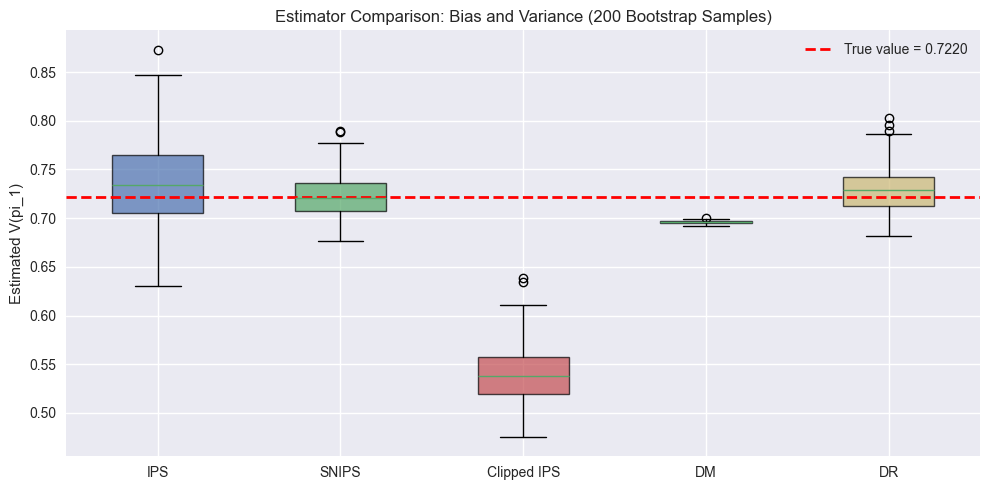


Estimator Statistics (Bootstrap):
  IPS              mean=0.7360  std=0.0441  bias=0.0140  MSE=0.002140
  SNIPS            mean=0.7224  std=0.0224  bias=0.0004  MSE=0.000504
  Clipped IPS      mean=0.5398  std=0.0277  bias=0.1821  MSE=0.033945
  DM               mean=0.6959  std=0.0016  bias=0.0261  MSE=0.000682
  DR               mean=0.7285  std=0.0228  bias=0.0065  MSE=0.000561


In [6]:
# Bootstrap to estimate variance of each estimator
n_bootstrap = 200
bootstrap_results = {'IPS': [], 'SNIPS': [], 'Clipped IPS': [], 'DM': [], 'DR': []}

for b in range(n_bootstrap):
    idx = rng.choice(N_CONTEXTS, size=N_CONTEXTS, replace=True)
    r_b = log_df['reward'].values[idx]
    p_b = log_df['propensity'].values[idx]
    t_b = log_df['target_prob'].values[idx]
    a_b = log_df['action'].values[idx]
    x_b = contexts[idx]
    
    bootstrap_results['IPS'].append(ips_estimator(r_b, p_b, t_b))
    bootstrap_results['SNIPS'].append(snips_estimator(r_b, p_b, t_b))
    bootstrap_results['Clipped IPS'].append(ips_estimator(r_b, p_b, t_b, clip=10.0))
    
    # DM and DR for bootstrap
    dm_vals = []
    dr_vals = []
    for i in range(len(idx)):
        x = x_b[i]
        pi1_full = target_policy_probs(x)
        dm_val = sum(pi1_full[aa] * estimated_reward(x, aa) for aa in range(K_ACTIONS))
        dm_vals.append(dm_val)
        w = t_b[i] / p_b[i]
        dr_vals.append(dm_val + w * (r_b[i] - estimated_reward(x, a_b[i])))
    bootstrap_results['DM'].append(np.mean(dm_vals))
    bootstrap_results['DR'].append(np.mean(dr_vals))

fig, ax = plt.subplots(figsize=(10, 5))
positions = list(range(len(bootstrap_results)))
bp = ax.boxplot([bootstrap_results[k] for k in bootstrap_results.keys()],
                labels=bootstrap_results.keys(), patch_artist=True)
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label=f'True value = {true_value:.4f}')
ax.set_ylabel('Estimated V(pi_1)')
ax.set_title('Estimator Comparison: Bias and Variance (200 Bootstrap Samples)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nEstimator Statistics (Bootstrap):")
for name, vals in bootstrap_results.items():
    vals = np.array(vals)
    print(f"  {name:15s}  mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"bias={abs(vals.mean()-true_value):.4f}  MSE={((vals-true_value)**2).mean():.6f}")

## 6. Propensity Estimation Methods

In practice, we often do not know the true propensity $\pi_0(a|x)$. We must estimate it.

Common approaches:
1. **Randomized logging**: Inject random exploration (known propensities)
2. **Logistic regression**: Model $P(a|x)$ using logged features
3. **Position-based estimation**: For position bias, estimate click probability by position

> **⚠️ Common Pitfall:** Estimated propensities that are too small can cause extreme variance. Always apply propensity clipping or use SNIPS when propensities are estimated.

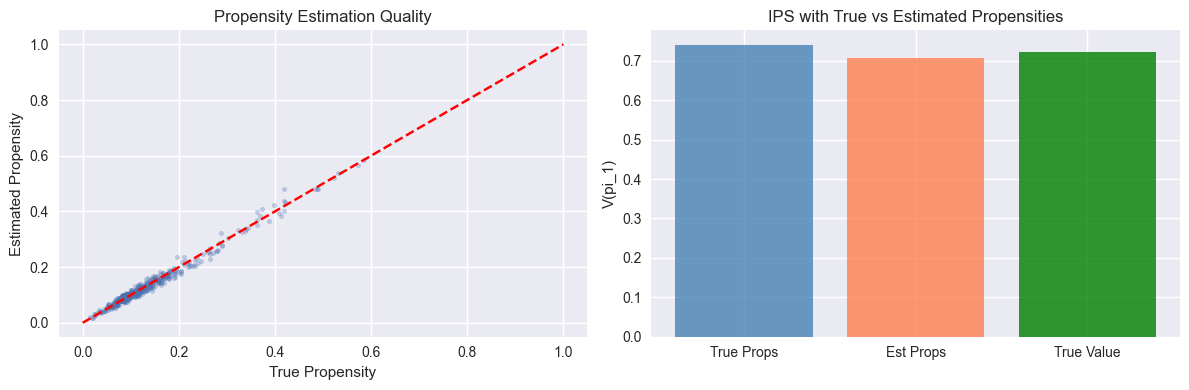

In [7]:
# Simulate propensity estimation via logistic regression
from sklearn.linear_model import LogisticRegression

# Train a logistic regression to estimate P(action | context)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(contexts, log_df['action'].values)

# Get estimated propensities
estimated_propensities = lr.predict_proba(contexts)
est_props = np.array([estimated_propensities[i, log_df['action'].values[i]]
                      for i in range(N_CONTEXTS)])

# Compare true vs estimated propensities
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(log_df['propensity'].values[:500], est_props[:500], alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], 'r--')
axes[0].set_xlabel('True Propensity')
axes[0].set_ylabel('Estimated Propensity')
axes[0].set_title('Propensity Estimation Quality')

# Effect on IPS estimate
ips_true_prop = ips_estimator(log_df['reward'].values, log_df['propensity'].values, log_df['target_prob'].values)
ips_est_prop = ips_estimator(log_df['reward'].values, est_props, log_df['target_prob'].values)

axes[1].bar(['True Props', 'Est Props', 'True Value'], 
            [ips_true_prop, ips_est_prop, true_value],
            color=['steelblue', 'coral', 'green'], alpha=0.8)
axes[1].set_ylabel('V(pi_1)')
axes[1].set_title('IPS with True vs Estimated Propensities')

plt.tight_layout()
plt.show()

## 7. Off-Policy Evaluation for Ranking

For ranking, we need to evaluate a full ranked list, not just a single action. The cascading model assumes users examine items top-to-bottom and stop after clicking.

Reference: Li et al., "Offline Evaluation of Ranking Policies with Click Models" (KDD 2018).

In [8]:
# Simplified ranking OPE: position-weighted IPS
# Simulate logged rankings and clicks
N_QUERIES = 1000
LIST_SIZE = 5

position_exam_prob = np.array([1.0, 0.8, 0.6, 0.4, 0.2])  # examination probability by position
item_relevance = rng.uniform(0, 1, size=(N_QUERIES, 20))  # 20 candidate items per query

# Logging policy: scores items with noise
logging_scores = item_relevance + rng.randn(N_QUERIES, 20) * 0.5
logging_rankings = np.argsort(-logging_scores, axis=1)[:, :LIST_SIZE]

# Target policy: better scorer
target_scores = item_relevance + rng.randn(N_QUERIES, 20) * 0.2
target_rankings = np.argsort(-target_scores, axis=1)[:, :LIST_SIZE]

# Simulate clicks under logging policy (examine-then-click model)
clicks = np.zeros((N_QUERIES, LIST_SIZE))
for q in range(N_QUERIES):
    for pos in range(LIST_SIZE):
        item_idx = logging_rankings[q, pos]
        examined = rng.random() < position_exam_prob[pos]
        if examined:
            clicked = rng.random() < item_relevance[q, item_idx]
            clicks[q, pos] = 1 if clicked else 0

# Naive evaluation: just compute CTR of target ranking (biased!)
# We cannot do this without deploying, so we use position-weighted IPS
# For each query, re-weight based on which items overlap

def ranking_ips(logging_rankings, target_rankings, clicks, position_exam_prob):
    """Simplified position-weighted IPS for ranking."""
    n_queries = len(logging_rankings)
    estimated_reward = 0.0
    
    for q in range(n_queries):
        query_reward = 0.0
        log_items = list(logging_rankings[q])
        
        for target_pos in range(len(target_rankings[q])):
            target_item = target_rankings[q, target_pos]
            if target_item in log_items:
                log_pos = log_items.index(target_item)
                # Re-weight by examination probability ratio
                weight = position_exam_prob[target_pos] / position_exam_prob[log_pos]
                query_reward += weight * clicks[q, log_pos]
        
        estimated_reward += query_reward
    
    return estimated_reward / n_queries

logging_ctr = clicks.sum() / (N_QUERIES * LIST_SIZE)
ips_ranking_est = ranking_ips(logging_rankings, target_rankings, clicks, position_exam_prob)

print(f"Logging policy CTR:          {logging_ctr:.4f}")
print(f"Ranking IPS estimate (pi_1): {ips_ranking_est:.4f}")

Logging policy CTR:          0.4202
Ranking IPS estimate (pi_1): 1.1625


## 8. Exercises

### Exercise 1: Implement IPS, SNIPS, and DR from Scratch

In [9]:
# 🏋️ Exercise 1: Implement and Compare Estimators
#
# TODO:
# 1. Implement IPS with propensity clipping at thresholds [1, 5, 10, 50, inf]
# 2. For each threshold, compute the MSE using 100 bootstrap samples
# 3. Plot MSE vs clipping threshold — what is the optimal threshold?
# 4. Compare with SNIPS and DR

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 2: Effect of Logging Policy Quality

In [10]:
# 🏋️ Exercise 2: Logging Policy Quality
#
# TODO: Investigate how the quality of the logging policy affects estimation.
# 1. Regenerate logged data with different logging temperatures:
#    temp = [0.1, 0.5, 1.0, 2.0, 5.0]
#    (Higher temp = more exploration = better coverage)
# 2. For each temperature, compute IPS, SNIPS, and DR estimates
# 3. Plot estimation error vs logging temperature
# 4. What temperature gives the best estimator quality?

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 3: Doubly Robust with Misspecified Models

In [11]:
# 🏋️ Exercise 3: DR Robustness
#
# TODO: Verify the double robustness property:
# 1. Compute DR with correct propensities + wrong reward model
# 2. Compute DR with wrong propensities + correct reward model
# 3. Compute DR with wrong propensities + wrong reward model
# 4. For "wrong" propensities, use uniform(1/K)
#    For "wrong" reward model, use constant 0.5
# 5. Show that DR is accurate in cases 1 and 2, but not case 3

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

## Summary

In this notebook we covered:

- **Counterfactual evaluation**: estimating the performance of new policies from logged data
- **IPS**: unbiased but high-variance; weight clipping trades bias for variance
- **SNIPS**: self-normalised for better variance; slight bias
- **Doubly Robust**: the gold standard — combines reward model + IPS correction; robust to one model being wrong
- **Propensity estimation**: necessary in practice; imperfect propensities affect all IPS-based methods
- **Ranking OPE**: extending counterfactual evaluation to ranked lists

**Key takeaway:** Counterfactual evaluation bridges the gap between offline and online evaluation. The DR estimator should be your default choice, with SNIPS as a simpler alternative when you lack a good reward model.